In [1]:
%%capture
!pip install keras-tuner --upgrade

In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import matplotlib.colors as colors
from mpl_toolkits import mplot3d
from math import sqrt
import warnings
import time

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.model_selection import train_test_split,KFold,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder, MinMaxScaler


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,ExtraTreesRegressor,BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

import keras_tuner as kt
from tensorflow import keras

import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping

import pickle
import os
import random


import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams['savefig.dpi'] = 300
plt.rcParams["savefig.format"] = 'tiff'
warnings.filterwarnings("ignore")

In [3]:
seed = 76
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)


In [4]:
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.7)

In [5]:
# To print losses
def plots():
    f, ax = plt.subplots(1,1)
    actual_val=np.array(scaler.inverse_transform(valY).reshape(-1,1))
    predicted_val=np.array(scaler.inverse_transform(model.predict(valX).reshape(-1,1)))
    actual_test=np.array(scaler.inverse_transform(testY).reshape(-1,1))
    predicted_test=np.array(scaler.inverse_transform(model.predict(testX).reshape(-1,1)))

    actual=np.array(scaler.inverse_transform(np.array(trainY).reshape(-1,1)))
    predicted=np.array(scaler.inverse_transform(model.predict(np.array(trainX)).reshape(-1,1)))

    plt.rcParams["figure.figsize"] = (6,6)
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams["savefig.format"] = 'tiff'

    sns.set(style='whitegrid')
    sns.set_context("paper", font_scale=1.7)

    plt.scatter(actual_test,predicted_test, color='purple', label='Test', linewidths=1, edgecolors='black', s=75)
    sns.regplot(x=actual,y=predicted, color='orangered', label='Train', scatter_kws={'s':40, 'alpha':0.5, 'edgecolor':'black'})
    print("R square (R^2) for train:                 %f" % r2_score(actual,predicted))
    print("R square (R^2) for val:                 %f" % r2_score(actual_val,predicted_val))
    print("Mean absolute error (MAE)- Test:      %f" % mean_absolute_error(actual_test,predicted_test))
    print("Mean squared error (MSE)- Test:       %f" % mean_squared_error(actual_test,predicted_test))
    print("Root mean squared error (RMSE) - Test: %f" % sqrt(mean_squared_error(actual_test,predicted_test)))
    print("R square (R^2) - Test:                 %f" % r2_score(actual_test,predicted_test))


    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    anchored_text = AnchoredText("R\u00b2 Score_train  "+str(round(r2_score(actual,predicted),3))+'\n'"R\u00b2 Score_test  "+str(round(r2_score(actual_test,predicted_test),3)), loc=2,prop=dict(size=10))
    ax.add_artist(anchored_text)

    plt.legend(loc = 9, prop={'size': 10})
    plt.tight_layout()
    plt.savefig(str(model)[1:6], bbox_inches='tight')

In [6]:
df = pd.read_excel(
    'data_final.xlsx'
)

In [7]:
df.head(2)

,Type,ID,Name,Cation smiles,Anion smiles,ET30,ABC,nBase,SpMax_A,VR1_A,...,An_EState_VSA2,An_EState_VSA4,An_EState_VSA5,An_EState_VSA8,An_EState_VSA9,An_VSA_EState3,An_VSA_EState7,An_AMID_O,An_AMID_X,An_n6HRing
0,ammonium salts,A1,[NH4] F3CCO2,[NH4+],FC(F)(C([O-])=O)F,43.6,0.000000,1,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,9.901065,8.784722,-5.194444,0.475336,0.709501,0
1,ammonium salts,A2,[EtNH3] Cl,CC[NH3+],[Cl-],62.3,1.414214,1,1.414214,3.363586,...,12.407033,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0


In [8]:
df.shape

(227, 174)

In [9]:
with open('train_ids.pkl', 'rb') as f:
    train_ids = pickle.load(f)


with open('test_ids.pkl', 'rb') as f:
    test_ids = pickle.load(f)

Train = df[df['ID'].isin(train_ids)].set_index('ID').loc[train_ids].reset_index()
Non_train = df[df['ID'].isin(test_ids)].set_index('ID').loc[test_ids].reset_index()

In [10]:
Val = Non_train.sample(frac=0.5, random_state=48)
Test = Non_train[~Non_train.index.isin(Val.index)]

In [11]:
Test.ID.values

array(['I46', 'I164', 'I27', 'I5', 'I18', 'A26', 'A23', 'A25', 'A30',
       'A5', 'A6', 'G27', 'G17', 'G5', 'G6', 'G23', 'G33', 'Y14', 'Y11',
       'M1', 'M11', 'P10', 'P12', 'E10', 'O4'], dtype=object)

In [12]:
Train.shape

(177, 174)

In [13]:
Test.shape

(25, 174)

In [14]:
Val.shape

(25, 174)

In [15]:
# Combine Train and test for feature engineering
DF_raw = pd.concat([Train,Val, Test],ignore_index=True)
DF_data = DF_raw.copy()

In [16]:
DF_data.shape

(227, 174)

In [17]:
# Removing Unwanted columns
DF_data=DF_data.drop(['Type', 'ID', 'Name', 'Cation smiles', 'Anion smiles'],axis=1)
DF_data.head(2)

,ET30,ABC,nBase,SpMax_A,VR1_A,nAromAtom,nHetero,nN,nO,nS,...,An_EState_VSA2,An_EState_VSA4,An_EState_VSA5,An_EState_VSA8,An_EState_VSA9,An_VSA_EState3,An_VSA_EState7,An_AMID_O,An_AMID_X,An_n6HRing
0,54.1,7.180458,1,2.236324,46.151834,5,3,2,1,0,...,0.000000,4.127401,0.000000,0.0,0.0,0.000000,0.000000,0.453779,0.667042,0
1,47.0,4.352030,1,2.114908,14.516293,5,2,2,0,0,...,6.420822,0.000000,6.923737,0.0,0.0,9.256944,0.111111,0.662611,0.000000,0


In [18]:
DF_data = DF_data[['ET30','ATSC1c', 'An_C1SP2',
                   'NsOH', 'ATSC1se', 'ATSC2Z', 'ABC', 'Xpc-4d',
       'An_ETA_shape_p', 'ATSC8Z', 'An_AETA_beta', 'An_VSA_EState7',
       'An_ETA_dEpsilon_D', 'JGI8', 'AATSC2Z', 'An_SpMax_A'
       ]]

In [19]:
# plt.figure(figsize=(20,20))
# corr = DF_data.corr()
# matrix = np.triu(corr)
# sns.heatmap(DF_data.corr(),cmap = "coolwarm",mask=matrix, annot=True, fmt=".1f", annot_kws={'fontsize': 20})
# plt.xticks(fontsize=10)
# plt.yticks(fontsize=10)
# plt.savefig('1st_Corr.png')

In [20]:
DF_data.head(2)

,ET30,ATSC1c,An_C1SP2,NsOH,ATSC1se,ATSC2Z,ABC,Xpc-4d,An_ETA_shape_p,ATSC8Z,An_AETA_beta,An_VSA_EState7,An_ETA_dEpsilon_D,JGI8,AATSC2Z,An_SpMax_A
0,54.1,-0.148680,0,0,0.023243,-21.073724,7.180458,0.777317,0.498442,-20.824197,1.033333,0.000000,0.0,0.0,-0.526843,2.449490
1,47.0,-0.195432,1,0,-0.043904,-11.526627,4.352030,0.408248,0.538462,0.000000,0.800000,0.111111,0.0,0.0,-0.548887,1.847759


In [21]:
# Scaling the whole DataFrame

scaler = StandardScaler()
scaled_DF = pd.DataFrame(scaler.fit_transform(DF_data.iloc[:,1:]))
scaled_DF.columns = DF_data.iloc[:,1:].columns

scaled_DF['ET30'] = scaler.fit_transform(np.array(DF_data['ET30']).reshape(-1,1))
scaled_DF

display(scaled_DF)

,ATSC1c,An_C1SP2,NsOH,ATSC1se,ATSC2Z,ABC,Xpc-4d,An_ETA_shape_p,ATSC8Z,An_AETA_beta,An_VSA_EState7,An_ETA_dEpsilon_D,JGI8,AATSC2Z,An_SpMax_A,ET30
0,-0.471771,-0.444426,-0.341240,-0.293030,0.376600,-0.578748,-0.866079,0.311770,-0.211875,0.117903,-0.172629,-0.278338,-0.633693,-0.133004,0.804173,0.522553
1,-1.000204,1.702056,-0.341240,-0.782258,0.574386,-1.157673,-1.546160,0.510639,0.139879,-0.361840,-0.112588,-0.278338,-0.633693,-0.179965,-0.071808,-0.838906
2,0.059560,-0.444426,-0.341240,0.392597,0.315976,-0.289286,-0.866079,0.727441,-0.434435,0.049368,-0.172629,-0.278338,2.638176,0.092361,0.590591,0.215745
3,-0.072947,-0.444426,-0.341240,0.276085,0.655071,-0.578748,-0.866079,1.384368,0.182041,-0.079135,-0.172629,-0.278338,-0.633693,0.628029,-0.240252,0.081517
4,-1.292949,-0.444426,1.548066,-1.589372,0.317737,-0.723479,-0.866079,-0.358126,0.444055,1.694200,1.212056,-0.278338,-0.633693,-0.509085,-0.240252,0.906063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,0.569118,-0.444426,-0.341240,0.665561,-0.405979,0.155045,0.347045,-0.358126,0.167651,1.694200,1.212056,-0.278338,0.806232,-0.485554,-0.240252,-0.436221
223,1.579963,-0.444426,-0.341240,-1.099045,-1.093113,0.267248,0.465604,-2.165157,0.496245,-2.006673,-0.172629,-0.278338,-0.633693,-0.932459,-2.761716,-1.605925
224,1.712337,-0.444426,-0.341240,-1.086050,-2.432319,1.425097,0.465604,-2.165157,0.278542,-2.006673,-0.172629,-0.278338,0.016168,-1.235547,-2.761716,-1.682627
225,-1.446351,-0.444426,3.437373,-1.912880,0.014246,-0.256759,0.983137,0.311770,0.393996,0.117903,-0.172629,-0.278338,-0.633693,-0.335732,0.804173,2.190820


In [22]:
DF_target = scaled_DF[['ET30']]
scaled_DF.drop('ET30',axis=1,inplace=True)

In [23]:
trainX = scaled_DF.iloc[:177, :]
valX = scaled_DF.iloc[177:202, :]
testX = scaled_DF.iloc[202:,:]

trainY = DF_target.iloc[:177, :]
valY = DF_target.iloc[177:202, :]
testY = DF_target.iloc[202:, :]

In [24]:
totalX = pd.concat([trainX,valX, testX], axis=0)
totalY = pd.concat([trainY, valY, testY], axis=0)

In [ ]:
# Define the learning rate scheduler
def scheduler(epoch, lr):
    if epoch < 160:
        return lr
    else:
        return lr * np.exp(-0.1)

callback = keras.callbacks.LearningRateScheduler(scheduler)

# Define the model builder for Keras Tuner
def model_builder(hp):
    init = keras.initializers.RandomNormal()
    model = Sequential()

    # Input layer
    model.add(layers.Dense(
        units=hp.Int('units_input', min_value=16, max_value=128, step=16),
        activation='relu',
        kernel_initializer=init,
        input_dim=scaled_DF.shape[1]
    ))
    model.add(layers.Dropout(hp.Float('dropout_input', min_value=0.1, max_value=0.5, step=0.1)))

    # Hidden layers
    for i in range(hp.Int('num_hidden_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'units_hidden_{i}', min_value=64, max_value=256, step=64),
            activation='relu',
            kernel_initializer=init
        ))
        model.add(layers.Dropout(hp.Float(f'dropout_hidden_{i}', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(layers.Dense(1, kernel_initializer=init, activation='linear'))

    # Optimizer and learning rate
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='mse')
    return model

# Initialize the tuner
tuner = kt.Hyperband(
    model_builder,
    objective='val_loss',
    max_epochs=200,
    factor=3,
    directory='my_dir',
    project_name='tuning_neural_network'
)

# Search for the best hyperparameters
tuner.search(
    trainX, trainY,
    epochs=200,
    batch_size=32,
    validation_data=(valX, valY),
    callbacks=[callback]
)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build and train the best model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    trainX, trainY,
    epochs=200,
     batch_size=32,
    validation_data=(valX, valY),
    callbacks=[callback],
    verbose=1
)

# Print the optimal hyperparameters
print("Optimal Hyperparameters:")
for param, value in best_hps.values.items():
    print(f"{param}: {value}")

Trial 254 Complete [00h 00m 34s]
val_loss: 0.33894646167755127

Best val_loss So Far: 0.23752418160438538
Total elapsed time: 00h 31m 19s
Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.7109 - val_loss: 0.8683 - learning_rate: 0.0100
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4958 - val_loss: 0.6907 - learning_rate: 0.0100
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3682 - val_loss: 0.7033 - learning_rate: 0.0100
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3719 - val_loss: 0.5489 - learning_rate: 0.0100
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2873 - val_loss: 0.4789 - learning_rate: 0.0100
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2283 - val_loss: 0.5861 - learning_rate: 0.0100
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2237 - val_loss: 0.4300 - learning_rate: 0.0100
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1642 - val_loss: 0.4382 - learning_rate: 0.010

In [26]:
# Learning Rate Scheduler
def scheduler(epoch, lr):
  if epoch < 160:
    return lr
  else:
    return lr * np.exp(-0.1)

callback = keras.callbacks.LearningRateScheduler(scheduler)

# Neural Network
def Neural_network():
    # Initialize weights with a random normal initializer
    init = keras.initializers.RandomNormal()
    model = Sequential()

    # Input Layer
    model.add(layers.Dense(
        128,
        activation='relu',
        kernel_initializer=init,
        input_dim=scaled_DF.shape[1]
    ))
    model.add(layers.Dropout(0.1))  # 40% dropout as per optimal parameters

    # first Hidden Layer
    model.add(layers.Dense(
        192,
        activation='relu',
        kernel_initializer=init
    ))
    model.add(layers.Dropout(0.1))  # 30% dropout as per optimal parameters

# second hidden
    model.add(layers.Dense(
            256,
            activation='relu',
            kernel_initializer=init
        ))
    model.add(layers.Dropout(0.4))

    # Output Layer
    model.add(layers.Dense(
        1,
        kernel_initializer=init,
        activation='linear'  # Linear activation for regression
    ))

    # Optimizer
    optimize = tf.keras.optimizers.Adam(learning_rate=0.01)  # Optimal learning rate

    # Compile the model
    model.compile(
        optimizer=optimize,
        loss='mse'  # Mean Squared Error for regression tasks
    )
    return model

# Training Function
def training_model(X_train, Y_train, model, X_val, Y_val):
    # Include callbacks: LearningRateScheduler and optional EarlyStopping
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=30,
        min_delta=0.001,
        restore_best_weights=True
    )

    history = model.fit(
        trainX, trainY,
        epochs=200,
        batch_size=32,
        validation_data=(valX, valY),  # Add validation data
        verbose=0,  # Set verbose to 1 for training logs
        callbacks=[callback, early_stopping]  # Add callbacks
    )
    return history


In [27]:
model = Neural_network()
# Define Callbacks

history = training_model(trainX, trainY, model, valX, valY)

In [29]:
model = load_model('/content/nn_tuned.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
R square (R^2) for train:                 0.954888
R square (R^2) for val:                 0.794898
Mean absolute error (MAE)- Test:      1.237292
Mean squared error (MSE)- Test:       3.266196
Root mean squared error (RMSE) - Test: 1.807262
R square (R^2) - Test:                 0.914065


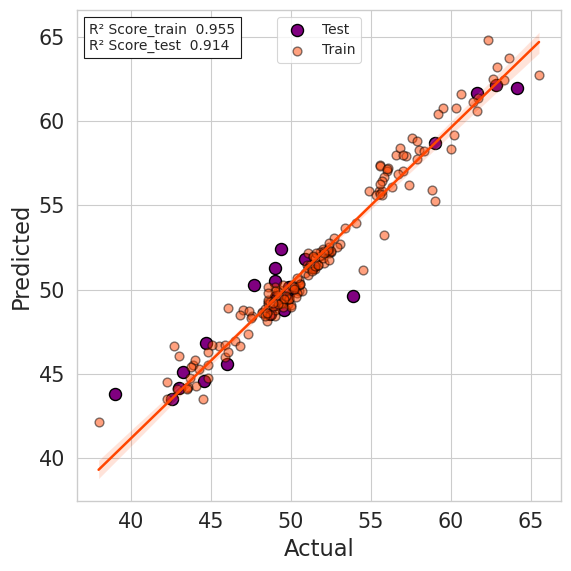

In [30]:
plots()